In [64]:
import pandas as pd
import numpy as np
from read_predictions import get_all_predictions
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import glob


In [65]:
scaler_values = []
for i in glob.glob(f"data/*_scaler_values.csv"):
    df = pd.read_csv(i)
    # remove .1 at the end of the column names if it exists
    df.columns = [col[:-2] if col.endswith('.1') else col for col in df.columns]
    scaler_values.append(df)
scaler_all = pd.concat(scaler_values, ignore_index=True)
scaler_all.sort_values(by='value', inplace=True)
scaler_all

,Tt.BMD,Tt.Ar,Tb.BMD,BV/TV,Tb.N,Tb.Th,Tb.Sp,Tb.1/N.SD,Tb.Ar,Ct.BMD,Ct.Th,Ct.Pm,Ct.Ar,value,bone,xct,Ct.Po,Ct.Po.Dm
0,224.376286,774.185429,138.357429,0.115286,1.636143,0.072143,0.601457,0.362817,666.628571,728.880286,0.769343,109.824000,83.927143,mean,tibia,XCT1,NaN,NaN
2,250.021429,290.328571,121.740857,0.101454,1.666657,0.061306,0.599711,0.345131,233.237714,743.894857,0.569743,72.853143,41.333714,mean,radius,XCT1,NaN,NaN
4,250.695429,299.441143,119.142286,0.174303,1.176177,0.227040,0.933114,0.480400,248.283714,832.140000,0.893520,73.634571,55.118857,mean,radius,XCT2,0.007391,0.175849
6,236.120286,772.768286,141.333714,0.215269,1.178563,0.257617,0.905069,0.466840,670.228571,803.234286,1.204054,108.672286,108.180857,mean,tibia,XCT2,0.030617,0.222389
1,51.542858,138.410783,36.737795,0.030612,0.419189,0.015213,0.280523,0.368400,136.080300,75.313530,0.274157,10.126401,30.278935,var,tibia,XCT1,NaN,NaN
3,58.382623,67.287627,36.912399,0.030770,0.422072,0.011886,0.283817,0.289964,61.656139,80.404929,0.193044,8.887856,14.760327,var,radius,XCT1,NaN,NaN
5,63.946346,73.566652,42.933028,0.056183,0.309479,0.017287,0.508059,0.459053,67.904147,86.434242,0.203718,9.581269,13.973209,var,radius,XCT2,0.005000,0.028673
7,58.483798,162.735240,41.351645,0.053251,0.264323,0.026323,0.437583,0.505802,159.349284,87.307665,0.302090,11.670698,28.051478,var,tibia,XCT2,0.015239,0.032499


In [66]:
data = pd.read_excel("data/Motion full matched_for_olga.xlsx", header=1)
pred_cols_radius = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
pred_cols_tibia = [f"{x}.1" for x in pred_cols_radius]
data = data.replace('-', np.nan)
# stack radius and tibia columns
stacked_cols = []
bone_labels = []
for c1, c2 in zip(pred_cols_radius, pred_cols_tibia):
    stacked = pd.concat([data[c1], data[c2]], ignore_index=True)
    stacked_cols.append(stacked)

    bone = pd.Series(['radius'] * len(data) + ['tibia'] * len(data))

data_orig = pd.concat(stacked_cols, axis=1)
data_orig.columns = pred_cols_radius
data_orig['XCT'] = data_orig['Ct.Po'].apply(lambda x: 'XCT1' if pd.isna(x) else 'XCT2')
data_orig['bone'] = bone

/tmp/ipykernel_4185649/3594028686.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace('-', np.nan)


In [ ]:
data_orig

In [68]:
all_preds = get_all_predictions()
all_preds = all_preds[['logits', 'model', 'balanced', 'true']].dropna()
all_preds = all_preds[all_preds['balanced'] == True]
all_preds['XCT'] = all_preds['model'].apply(lambda x: x.split(' ')[1])
all_preds['bone'] = all_preds['model'].apply(lambda x: x.split(' ')[0])
all_preds = all_preds.rename(columns={'logits': 'LogReg log-odds'})
all_preds['true'] = all_preds['true'].apply(lambda x: 'usable' if x == 'pass' else 'unusable')
all_preds = all_preds[['LogReg log-odds', 'XCT', 'true', 'bone']]

all_preds

,LogReg log-odds,XCT,true,bone
2000,-0.774877,XCT1,usable,Tibia
2001,1.404754,XCT1,usable,Tibia
2002,4.456714,XCT1,unusable,Tibia
2003,-0.490175,XCT1,usable,Tibia
2004,-3.118239,XCT1,usable,Tibia
...,...,...,...,...
3995,-2.042178,XCT2,usable,Radius
3996,-2.184480,XCT2,usable,Radius
3997,-0.706877,XCT2,usable,Radius
3998,-1.811273,XCT2,usable,Radius


In [ ]:
# combine step PROBLEM: the order is only locally the same. So for each XCT and bone combination, order works. 
data_filtered = data_orig.copy()
log_odds = []
usability = []
# THIS WORKS ONLY BECAUSE THE INDEX ORDERS HERE ARE THE SAME AS IN data_orig
for combination in [('XCT1', 'radius'), ('XCT2', 'radius'), ('XCT1', 'tibia'), ('XCT2', 'tibia')]:
    xct, bone = combination
    # get indices from data_orig
    indices = data_orig[(data_orig['XCT'] == xct) & (data_orig['bone'] == bone)].index
    log_odds.extend(all_preds[(all_preds['XCT'] == xct) & (all_preds['bone'] == bone.capitalize())]['LogReg log-odds'].values)
    usability.extend(all_preds[(all_preds['XCT'] == xct) & (all_preds['bone'] == bone.capitalize())]['true'].values)

print(len(usability), len(log_odds), len(indices))
data_filtered['LogReg log-odds'] = pd.Series(log_odds)
data_filtered['usability'] = pd.Series(usability)
data_filtered

In [70]:
bone = ['radius', 'tibia']
xct = ['XCT1', 'XCT2']

full_df = pd.DataFrame(columns=['feature', 'coefficient', 'bone', 'xct', 'model'])

for b in bone:
    for x in xct:
        df = pd.read_csv(f'data/coefficients_{x}_{b}_balanced.csv')
        df['bone'] = b
        df['xct'] = x
        df['model'] = "balanced"

        full_df = pd.concat([full_df, df], ignore_index=True)

# remove .1 from feature name if it exists at the end
full_df['feature'] = full_df['feature'].str.replace(r'\.1$', '', regex=True)
full_df.head()

/tmp/ipykernel_4185649/1404973086.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([full_df, df], ignore_index=True)


,feature,coefficient,bone,xct,model
0,Tt.BMD,0.000000,radius,XCT1,balanced
1,Tt.Ar,0.000000,radius,XCT1,balanced
2,Tb.BMD,-1.246039,radius,XCT1,balanced
3,BV/TV,-1.369055,radius,XCT1,balanced
4,Tb.N,3.213962,radius,XCT1,balanced


In [71]:
full_df_bal = full_df[full_df['model'] == 'balanced']

## Simplified formula over all

In [104]:
columns = scaler_all.columns.tolist()
columns.remove('Ct.Po.Dm')  # Ct.Po.Dm is not in xct1
columns.remove('Ct.Po')  # Ct.Po is not in xct1
columns.remove('bone')
columns.remove('xct')  # xct is not in xct1
scaler_comb = scaler_all[columns].copy()

In [105]:
# avg each column by value
scaler_all_avg = scaler_comb.groupby('value').mean().reset_index()
scaler_all_avg

,value,Tt.BMD,Tt.Ar,Tb.BMD,BV/TV,Tb.N,Tb.Th,Tb.Sp,Tb.1/N.SD,Tb.Ar,Ct.BMD,Ct.Th,Ct.Pm,Ct.Ar
0,mean,240.303357,534.180857,130.143571,0.151578,1.414385,0.154526,0.759838,0.413797,454.594643,777.037357,0.859165,91.246000,72.140143
1,var,58.088906,110.500076,39.483717,0.042704,0.353766,0.017678,0.377496,0.405805,106.247468,82.365091,0.243252,10.066556,21.765987


In [107]:
# use Tb.N, Tb.1/N.SD, Tb.Sp, BV/TV
scaler_all_avg = scaler_all_avg[['Tb.N', 'Tb.1/N.SD', 'Tb.Sp', 'BV/TV', 'value']]
scaler_all_avg

,Tb.N,Tb.1/N.SD,Tb.Sp,BV/TV,value
0,1.414385,0.413797,0.759838,0.151578,mean
1,0.353766,0.405805,0.377496,0.042704,var


In [109]:
full_df_bal = full_df[full_df['model'] == 'balanced']
grouped_df = full_df_bal.groupby(['feature']).agg({'coefficient': 'mean'}).reset_index()
grouped_df = grouped_df.sort_values(by=['coefficient'], ascending=[False])
grouped_df['model'] = 'weighted'
grouped_df.reset_index(drop=True, inplace=True)
grouped_df = grouped_df.drop_duplicates(subset=['feature', 'model'])
grouped_df['bone'] = 'combined'
grouped_df['xct'] = 'combined'
grouped_df = grouped_df[grouped_df['model'] != 'unweighted']
grouped_df

,feature,coefficient,model,bone,xct
0,Tb.1/N.SD,2.543593,weighted,combined,combined
1,Tb.N,2.459490,weighted,combined,combined
2,Ct.Th,0.613543,weighted,combined,combined
3,Tb.Th,0.544106,weighted,combined,combined
4,Ct.Ar,0.210440,weighted,combined,combined
5,Ct.Pm,-0.105233,weighted,combined,combined
6,Ct.Po,-0.285644,weighted,combined,combined
7,Tb.BMD,-0.311510,weighted,combined,combined
8,Tt.Ar,-0.418260,weighted,combined,combined
9,Tb.Ar,-0.436634,weighted,combined,combined


In [111]:
features_of_interest = scaler_all_avg.columns[:-1].tolist()  # Exclude 'value' column
grouped_df = grouped_df[grouped_df['feature'].isin(features_of_interest)][['feature', 'coefficient']]
grouped_df

,feature,coefficient
0,Tb.1/N.SD,2.543593
1,Tb.N,2.459490
13,BV/TV,-1.758107
14,Tb.Sp,-2.086317


In [112]:
weight_row = grouped_df.set_index('feature').T
weight_row['value'] = 'weight'

scaler_all_avg = pd.concat([scaler_all_avg, weight_row[scaler_all_avg.columns]], ignore_index=True)
scaler_all_avg

,Tb.N,Tb.1/N.SD,Tb.Sp,BV/TV,value
0,1.414385,0.413797,0.759838,0.151578,mean
1,0.353766,0.405805,0.377496,0.042704,var
2,2.459490,2.543593,-2.086317,-1.758107,weight


In [127]:
def simple_calculate_score(row):
    """
    Calculate the score based on the provided row.
    """
    score = 0
    formula_str = "score = "
    cols = scaler_all_avg.columns[:-1]  # Exclude 'value' column
    for col in cols:
        if col not in row:
            continue
        mean = scaler_all_avg[scaler_all_avg['value'] == 'mean'][col].values[0]
        std = scaler_all_avg[scaler_all_avg['value'] == 'var'][col].values[0]
        weight = scaler_all_avg[scaler_all_avg['value'] == 'weight'][col].values[0]
                # round all values to 3 decimal places
        mean = round(mean, 3)
        std = round(std, 3)
        weight = round(weight, 3)
        score += ((row[col] - mean) / std) * weight

        formula_str += f"({col} - {mean}) / {std} * {weight} + "
    formula_str = formula_str.rstrip(' + ')  # Remove the trailing ' + '
    print(f"Formula for {row['bone']} {row['XCT']}: {formula_str}")
    return score

In [ ]:
data_filtered['simple_score'] = data_filtered.apply(simple_calculate_score, axis=1)
data_filtered

# Simplified formula per xct gen

In [ ]:
scaler_all

In [136]:
full_df_bal.head()

,feature,coefficient,bone,xct,model
0,Tt.BMD,0.000000,radius,XCT1,balanced
1,Tt.Ar,0.000000,radius,XCT1,balanced
2,Tb.BMD,-1.246039,radius,XCT1,balanced
3,BV/TV,-1.369055,radius,XCT1,balanced
4,Tb.N,3.213962,radius,XCT1,balanced


In [137]:
# pivot full_df_bal to have features as columns
full_df_bal_pivot = full_df_bal.pivot_table(index=['bone', 'xct', 'model'], 
                                             columns='feature', 
                                             values='coefficient',
                                             aggfunc='mean').reset_index()
full_df_bal_pivot.columns.name = None  # Remove the name of the columns index
full_df_bal_pivot = full_df_bal_pivot.drop(columns=['model'])
full_df_bal_pivot['value'] = 'weight'
full_df_bal_pivot

,bone,xct,BV/TV,Ct.Ar,Ct.BMD,Ct.Pm,Ct.Po,Ct.Po.Dm,Ct.Th,Tb.1/N.SD,Tb.Ar,Tb.BMD,Tb.N,Tb.Sp,Tb.Th,Tt.Ar,Tt.BMD,value
0,radius,XCT1,-1.369055,0.000000,-1.191211,0.000000,NaN,NaN,0.495455,2.553206,-0.694407,-1.246039,3.213962,-1.839012,0.064160,0.000000,0.000000,weight
1,radius,XCT2,-3.566812,0.000000,-0.966187,-0.420932,-0.349064,-0.597754,0.518188,2.018923,-0.214683,0.000000,2.619426,-1.748069,1.656032,-0.129539,-0.072664,weight
2,tibia,XCT1,0.373831,0.841759,-1.171298,0.000000,NaN,NaN,0.000000,2.658669,-0.005750,0.000000,1.188172,-1.771093,-1.365725,-0.851592,-0.730836,weight
3,tibia,XCT2,-2.470393,0.000000,-0.906837,0.000000,-0.222225,-0.893342,1.440530,2.943576,-0.831698,0.000000,2.816401,-2.987092,1.821957,-0.691909,-2.649449,weight


In [ ]:
combined_df = pd.concat([scaler_all, full_df_bal_pivot], ignore_index=True)
combined_df

In [156]:
def combination_calculate_score(row, important_cols=None, show_str=False):
    """
    Calculate the score based on the provided row.
    """
    if not important_cols:
        important_cols = ["Tb.N", "Tb.Sp", "BV/TV", "Tb.1/N.SD"]
    score = 0
    formlua_str = "score = "
    cols = combined_df[combined_df['xct'] == row['XCT']]
    if cols.empty:
        print(f"Nothing found for: {row['bone']} {row['XCT']}")
        return np.nan
    for i, col in enumerate(important_cols):
        mean = np.mean(cols[cols['value'] == 'mean'][col].values) # get the average value
        std = np.mean(cols[cols['value'] == 'var'][col].values)
        coef = np.mean(cols[cols['value'] == 'weight'][col].values)
        mean = round(mean, 3)
        std = round(std, 3)
        coef = round(coef, 3)
        partial_score = ((row[col] - mean) / std) * coef
        formlua_str += f"({col} - {mean}) / {std} * {coef} + "
        # print(f"Adding {partial_score} for {col} with mean {mean}, std {std}, weight {coef} and value {row[col]}")
        score += partial_score
    
    if show_str:
        formlua_str += formlua_str.rstrip(' + ')  # Remove the trailing ' + '
        print(f"Formula for {row['bone']} {row['XCT']}: {formlua_str}")

    return score

In [157]:
combination_calculate_score(data_filtered.iloc[-1], show_str=True)

Formula for tibia XCT2: score = (Tb.N - 1.177) / 0.287 * 2.718 + (Tb.Sp - 0.919) / 0.473 * -2.368 + (BV/TV - 0.195) / 0.055 * -3.019 + (Tb.1/N.SD - 0.474) / 0.482 * 2.481 + score = (Tb.N - 1.177) / 0.287 * 2.718 + (Tb.Sp - 0.919) / 0.473 * -2.368 + (BV/TV - 0.195) / 0.055 * -3.019 + (Tb.1/N.SD - 0.474) / 0.482 * 2.481


np.float64(0.6186291603699254)

In [ ]:
data_filtered['split_score'] = data_filtered.apply(combination_calculate_score, axis=1)
data_filtered

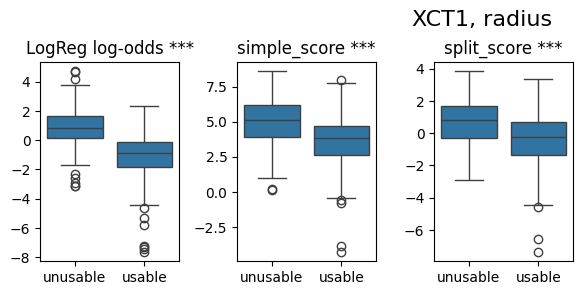

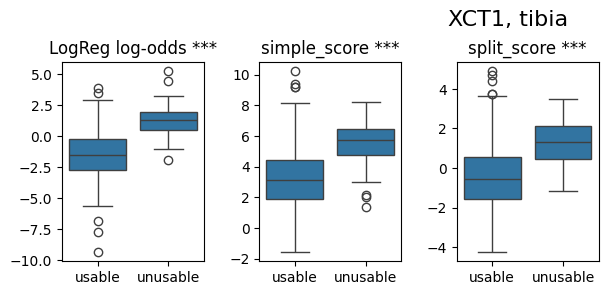

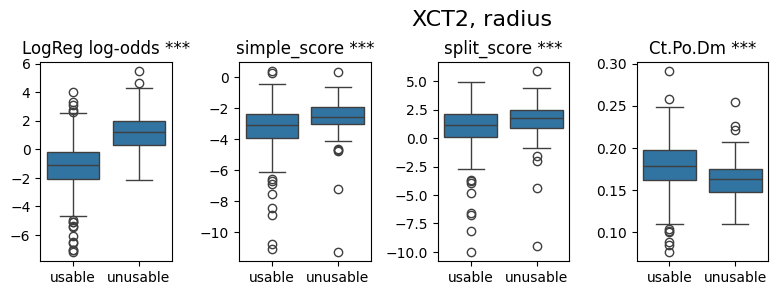

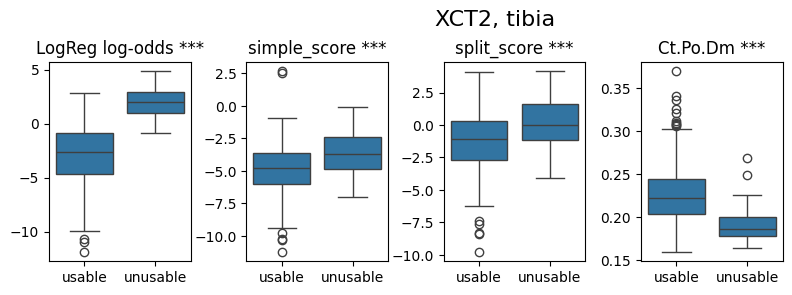

In [159]:
for xct in data_filtered['XCT'].unique():
    for bone in data_filtered['bone'].unique():
        data_xct = data_filtered[(data_filtered['XCT'] == xct) & (data_filtered['bone'] == bone)]
        fig = plt.figure(figsize=(10, 10))
        # if xct1, skip Ct.Po and Ct.Po.Dm
        if xct == 'XCT1':
            # copy pred_cols_radius and remove Ct.Po and Ct.Po.Dm
            pred_cols = pred_cols_radius.copy()
            pred_cols.remove('Ct.Po')
            pred_cols.remove('Ct.Po.Dm')

        else:
            pred_cols = pred_cols_radius
        
        all_cols = ['LogReg log-odds', 'simple_score', 'split_score', 'Ct.Po.Dm']
        for i, col in enumerate(all_cols):
            if data_xct[col].isna().all():
                continue
            ax = fig.add_subplot(4, 5, i+1)
            _, p = mannwhitneyu(data_xct[data_xct['usability'] == 'usable'][col], data_xct[data_xct['usability'] == 'unusable'][col])
            # check class of p
            if p > 0.05:
                p_str = ""
            elif p > 0.01:
                p_str = "*"
            elif p > 0.001:
                p_str = "**"
            else:
                p_str = "***"
            sns.boxplot(x='usability', y=col, data=data_xct)
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.set_title(f"{col} {p_str}")
        # set overarching title
        plt.suptitle(f"{xct}, {bone}", fontsize=16)
        plt.tight_layout()
        plt.show()